# 🚗 Accident Severity Prediction — v3 · Scale Edition
### 7 M Records · Precision–Recall Tradeoff · Skewness-Aware · Production-Speed

| Problem | Solution |
|---------|----------|
| **7 M rows → memory crash** | `int8/float32` dtypes on load + `gc.collect()` throughout |
| **SMOTE OOM on 5.6 M train rows** | `BorderlineSMOTE` on stratified **10 % sample** |
| **Optuna too slow** | 20% HPO subsample + 2-fold CV + LGB early-stopping per trial |
| **LightGBM slow on 7 M** | `data_sample_strategy='goss'` + `num_leaves=63` + `n_jobs=-1` |
| **Stacking too slow** | 30% subsample, `tree_method='hist'` (XGB), `passthrough=False` |
| **Skewness** | BorderlineSMOTE + `class_weight='balanced'` + per-class β-threshold tuning |
| **Precision–Recall tradeoff** | F-β sweep per class (β=2 for rare Sev 1 & 4) + F-β surface |


## 1 · Imports & Global Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc, json, time, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost  import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import BorderlineSMOTE

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Config ────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
SMOTE_FRAC   = 0.10   # fraction of train set for BorderlineSMOTE
HPO_FRAC     = 0.20   # fraction of train set for Optuna trials
STACK_FRAC   = 0.30   # fraction of train set for stacking
N_TRIALS     = 30     # increase to 80+ for production
BETA_CHOICE  = {1: 2.0, 2: 1.0, 3: 1.0, 4: 2.0}   # β per severity class

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
print("All libraries imported")


All libraries imported


## 2 · Memory-Efficient Data Loading
> **Technique:** cast every column to the smallest safe dtype at read time.
> `float64→float32` halves numeric RAM; `object→category` compresses strings.
> On 7 M rows this typically saves **2–4 GB**.


In [2]:
DATA_PATH = '/kaggle/input/datasets/dinaalielharedy/clean-version-accident/Clean_Version_Accident.csv'

# Step 1: infer dtype map from a tiny sample
sample = pd.read_csv(DATA_PATH, nrows=500)

def build_dtype_map(df, target='Severity'):
    m = {}
    for col in df.columns:
        if col == target:
            m[col] = 'int8'; continue
        s = df[col]
        if s.dtype == object:
            m[col] = 'category'
        elif np.issubdtype(s.dtype, np.floating):
            m[col] = 'float32'
        elif np.issubdtype(s.dtype, np.integer):
            mn, mx = s.min(), s.max()
            if   mn >= -128   and mx <= 127:   m[col] = 'int8'
            elif mn >= -32768 and mx <= 32767:  m[col] = 'int16'
            else:                               m[col] = 'int32'
        else:
            m[col] = s.dtype
    return m

dtype_map = build_dtype_map(sample)

# Step 2: full read
t0 = time.time()
dff = pd.read_csv(DATA_PATH, dtype=dtype_map, low_memory=False)
print(f"Loaded  : {len(dff):,} rows in {time.time()-t0:.1f}s")
print(f"RAM used: {dff.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"\nSeverity distribution:")
print(dff['Severity'].value_counts().sort_index())
gc.collect()


Loaded  : 7,728,394 rows in 149.8s
RAM used: 2.32 GB

Severity distribution:
Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64


0

## 3 · Skewness & Class Imbalance Visualisation

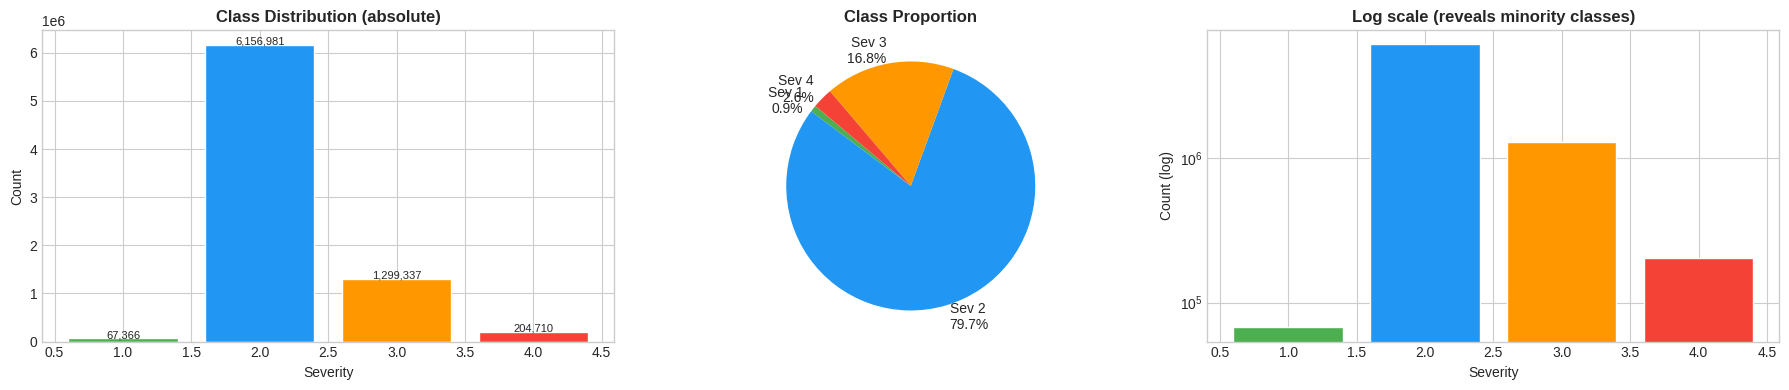

Imbalance ratio (max/min): 91.4x
Majority class share : 79.7%
Minority class share : 0.87%


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
counts = dff['Severity'].value_counts().sort_index()
colors = ['#4CAF50','#2196F3','#FF9800','#F44336']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (absolute)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity'); axes[0].set_ylabel('Count')
for i, v in zip(counts.index, counts.values):
    axes[0].text(i, v+5000, f'{v:,}', ha='center', fontsize=8)

pct = counts / counts.sum() * 100
axes[1].pie(pct, labels=[f'Sev {i}\n{p:.1f}%' for i,p in zip(pct.index, pct)],
            colors=colors, startangle=140)
axes[1].set_title('Class Proportion', fontsize=12, fontweight='bold')

axes[2].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[2].set_yscale('log')
axes[2].set_title('Log scale (reveals minority classes)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Severity'); axes[2].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

ratio = counts.max() / counts.min()
print(f"Imbalance ratio (max/min): {ratio:.1f}x")
print(f"Majority class share : {counts.max()/counts.sum()*100:.1f}%")
print(f"Minority class share : {counts.min()/counts.sum()*100:.2f}%")


## 4 · Feature Engineering — Vectorised & Memory-Safe
> All ops are vectorised (no Python row-loops).
> Dtypes are kept at `float32`/`int8` throughout.


In [4]:
t0 = time.time()

# Day/Night binary
d_n_col = ["Civil_Twilight","Sunrise_Sunset","Nautical_Twilight","Astronomical_Twilight"]
night_map = {"Night": np.int8(1), "Day": np.int8(0)}
for col in d_n_col:
    if col in dff.columns:
        dff[col] = dff[col].map(night_map).astype('int8')

# Boolean -> int8
T_F = ["Amenity","Bump","Crossing","Give_Way","Junction","No_Exit","Railway",
       "Roundabout","Station","Stop","Traffic_Calming","Traffic_Signal","Turning_Loop"]
for col in T_F:
    if col in dff.columns:
        dff[col] = dff[col].astype('int8')

# Split
X = dff.drop("Severity", axis=1)
y = dff["Severity"].astype('int8')
del dff; gc.collect()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
del X; gc.collect()
print(f"Train {X_train.shape} | Test {X_test.shape}")


Train (6182715, 54) | Test (1545679, 54)


In [5]:
# Frequency encoding (vectorised, categorical-safe)
def frequency_encoding(tr, te, cols):
    for col in cols:
        if col not in tr.columns: continue
        freq = tr[col].value_counts()
        # De-categorise BEFORE mapping to avoid "new category" TypeError
        tr_raw = tr[col].astype(str) if hasattr(tr[col], 'cat') else tr[col]
        te_raw = te[col].astype(str) if hasattr(te[col], 'cat') else te[col]
        tr[col] = tr_raw.map(freq).fillna(0).astype('float32')
        te[col] = te_raw.map(freq).fillna(0).astype('float32')

frequency_encoding(X_train, X_test,
    ["City","County","State","Timezone","Weather_Condition","Wind_Direction"])

# Drop metadata
cols_drop = [
    'Unnamed: 0','Source','Start_Time','End_Time','Start_Date','End_Date',
    'Start_Time_new','End_Time_New','Country','Timezone','Zipcode',
    'Start_Time_only','End_Time_only','Accident_Duration_Hours'
]
X_train.drop(columns=cols_drop, inplace=True, errors='ignore')
X_test.drop(columns=cols_drop,  inplace=True, errors='ignore')

# Align columns
for col in set(X_train.columns) - set(X_test.columns):
    X_test[col] = np.float32(0)
X_test = X_test[X_train.columns]

# Cyclical encoding (vectorised)
def add_cyclical(df, col, period):
    if col not in df.columns: return
    v = df[col].astype('float32')
    df[f'{col}_sin'] = np.sin(2*np.pi*v/period).astype('float32')
    df[f'{col}_cos'] = np.cos(2*np.pi*v/period).astype('float32')

cyc_specs = [('Hour_Start',24),('Hour_End',24),
             ('Minutes_Start',60),('Minutes_End',60),
             ('Day_of_Week',7),('Month',12)]
for df in [X_train, X_test]:
    for col, period in cyc_specs:
        add_cyclical(df, col, period)

X_train.drop(columns=[c for c,_ in cyc_specs], inplace=True, errors='ignore')
X_test.drop(columns=[c for c,_ in cyc_specs],  inplace=True, errors='ignore')

# Convert residual categoricals
for df in [X_train, X_test]:
    for col in df.select_dtypes('category').columns:
        df[col] = df[col].cat.codes.astype('float32')
    for col in df.select_dtypes(np.floating).columns:
        df[col] = df[col].astype('float32')

# Scale
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler   = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols]).astype('float32')
X_test[num_cols]  = scaler.transform(X_test[num_cols]).astype('float32')

train, test = X_train, X_test
del X_train, X_test; gc.collect()

print(f"Features : {train.shape[1]}")
print(f"Train RAM: {train.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"Elapsed  : {time.time()-t0:.1f}s")


Features : 46
Train RAM: 1.19 GB
Elapsed  : 31.8s


## 5 · Skewness Fix — BorderlineSMOTE on Stratified 10% Sample
> Full SMOTE on 5.6 M rows = OOM. Strategy:
> 1. Draw a **stratified 10% sample**.
> 2. Apply `BorderlineSMOTE` — synthesises only near the decision boundary (higher quality).
> 3. Train one model on this balanced set; complemented by `class_weight='balanced'` on full data.


In [6]:
t0 = time.time()
tr_s, _, y_s, _ = train_test_split(
    train, y_train, train_size=SMOTE_FRAC,
    stratify=y_train, random_state=RANDOM_STATE)
print(f"SMOTE sample: {len(tr_s):,} rows")
print(f"Before: {dict(pd.Series(y_s.astype(int)).value_counts().sort_index())}")

bsmote = BorderlineSMOTE(k_neighbors=5, kind='borderline-1',
                          random_state=RANDOM_STATE)
train_sm, y_sm = bsmote.fit_resample(tr_s, y_s)
train_sm = pd.DataFrame(train_sm, columns=train.columns).astype('float32')
y_sm     = pd.Series(y_sm.astype('int8'))

print(f"After : {dict(pd.Series(y_sm.astype(int)).value_counts().sort_index())}")
print(f"SMOTE time: {time.time()-t0:.1f}s")
del tr_s, y_s; gc.collect()


SMOTE sample: 618,271 rows
Before: {1: np.int64(5389), 2: np.int64(492558), 3: np.int64(103947), 4: np.int64(16377)}
After : {1: np.int64(492558), 2: np.int64(492558), 3: np.int64(492558), 4: np.int64(492558)}
SMOTE time: 263.5s


0

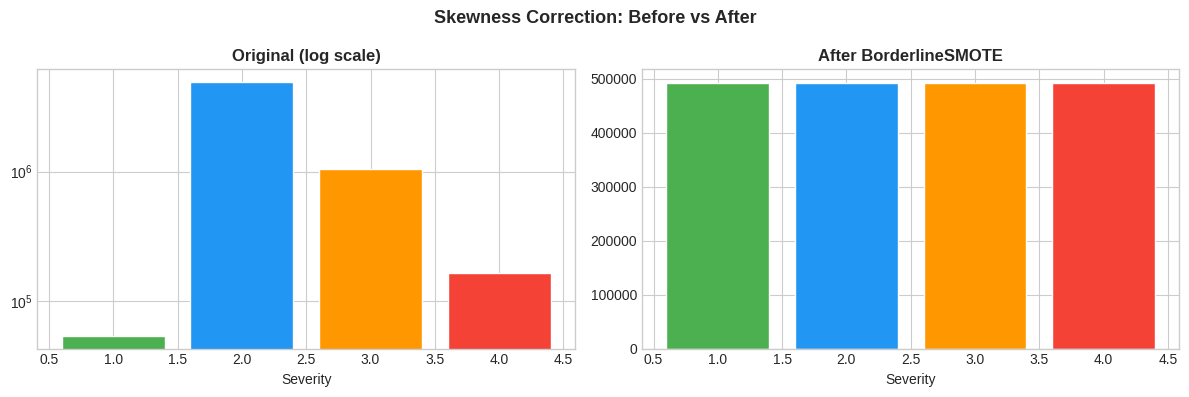

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4CAF50','#2196F3','#FF9800','#F44336']
orig  = pd.Series(y_train.astype(int)).value_counts().sort_index()
after = pd.Series(y_sm.astype(int)).value_counts().sort_index()

axes[0].bar(orig.index, orig.values, color=colors, edgecolor='white')
axes[0].set_yscale('log'); axes[0].set_title('Original (log scale)', fontweight='bold')
axes[0].set_xlabel('Severity')

axes[1].bar(after.index, after.values, color=colors, edgecolor='white')
axes[1].set_title('After BorderlineSMOTE', fontweight='bold')
axes[1].set_xlabel('Severity')

plt.suptitle('Skewness Correction: Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 6 · Baseline LightGBM (GOSS — speed-optimised for 7 M rows)
> `data_sample_strategy='goss'` keeps gradient-rich samples, discards small-gradient ones.
> Gives near-full-data accuracy at ~3× less compute.


In [8]:
classes    = np.sort(np.unique(y_train)).astype(int)
y_test_bin = label_binarize(y_test, classes=classes)

cw_vals = compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict = dict(zip(classes, cw_vals))
print("Class weights:", {k: round(v,2) for k,v in cw_dict.items()})

t0 = time.time()
lgb_base = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=63,
    max_depth=-1, max_bin=255,
    data_sample_strategy='goss',
    class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
lgb_base.fit(train, y_train)
print(f"Train time: {time.time()-t0:.1f}s")

y_pred_base = lgb_base.predict(test)
y_prob_base = lgb_base.predict_proba(test)

print("\n=== Baseline LGB (GOSS) ===")
print(f"Macro F1 : {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_bin, y_prob_base, multi_class='ovr'):.4f}")
print(classification_report(y_test, y_pred_base))


Class weights: {np.int64(1): np.float64(28.68), np.int64(2): np.float64(0.31), np.int64(3): np.float64(1.49), np.int64(4): np.float64(9.44)}
Train time: 557.1s

=== Baseline LGB (GOSS) ===
Macro F1 : 0.5503
ROC-AUC  : 0.9414
              precision    recall  f1-score   support

           1       0.29      0.96      0.45     13473
           2       0.98      0.71      0.82   1231396
           3       0.54      0.82      0.65    259868
           4       0.17      0.86      0.28     40942

    accuracy                           0.73   1545679
   macro avg       0.49      0.84      0.55   1545679
weighted avg       0.88      0.73      0.78   1545679



## 7 · Optuna HPO — Speed-Tuned
> Each trial uses a **20% subsample + 2-fold CV + early-stopping (50 rounds)**.
> Optimises **macro-F1** to care about minority classes.


In [9]:
tr_hpo, _, y_hpo, _ = train_test_split(
    train, y_train, train_size=HPO_FRAC,
    stratify=y_train, random_state=RANDOM_STATE)
print(f"HPO subsample: {len(tr_hpo):,} rows")

def objective(trial):
    p = dict(
        n_estimators         = trial.suggest_int('n_estimators', 200, 600, step=50),
        learning_rate        = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves           = trial.suggest_int('num_leaves', 31, 127),
        max_depth            = trial.suggest_int('max_depth', 4, 10),
        min_child_samples    = trial.suggest_int('min_child_samples', 20, 300),
        subsample            = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree     = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha            = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda           = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        data_sample_strategy = 'goss',
        class_weight         = 'balanced',
        random_state         = RANDOM_STATE, n_jobs=-1, verbose=-1,
    )
    model  = LGBMClassifier(**p)
    cv     = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tri, vali in cv.split(tr_hpo, y_hpo):
        model.fit(tr_hpo.iloc[tri], y_hpo.iloc[tri],
                  eval_set=[(tr_hpo.iloc[vali], y_hpo.iloc[vali])],
                  callbacks=[early_stopping(50, verbose=False), log_evaluation(-1)])
        scores.append(f1_score(y_hpo.iloc[vali], model.predict(tr_hpo.iloc[vali]),
                               average='macro'))
    return np.mean(scores)

study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

del tr_hpo, y_hpo; gc.collect()

best_params = {**study.best_params,
               'data_sample_strategy':'goss', 'class_weight':'balanced',
               'random_state':RANDOM_STATE, 'n_jobs':-1, 'verbose':-1}
print(f"\nBest macro-F1 (CV): {study.best_value:.4f}")
print(json.dumps({k:v for k,v in best_params.items()
                  if k not in ['class_weight','random_state','n_jobs',
                               'verbose','data_sample_strategy']}, indent=2))


HPO subsample: 1,236,543 rows


  0%|          | 0/30 [00:00<?, ?it/s]


Best macro-F1 (CV): 0.6497
{
  "n_estimators": 600,
  "learning_rate": 0.0972164315669934,
  "num_leaves": 106,
  "max_depth": 10,
  "min_child_samples": 92,
  "subsample": 0.650724933956525,
  "colsample_bytree": 0.75482197989205,
  "reg_alpha": 0.0005721943101060207,
  "reg_lambda": 1.3893632482584222
}


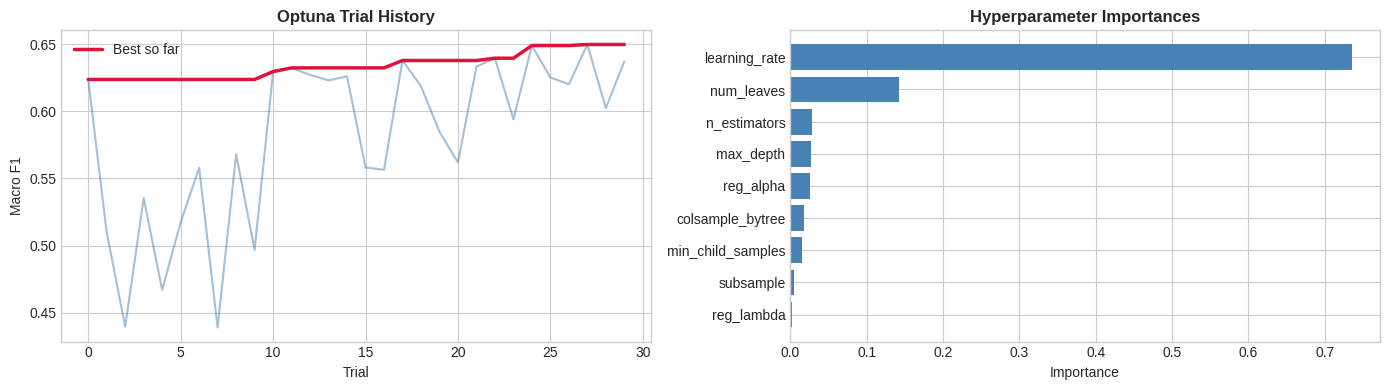

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
vals = [t.value for t in study.trials if t.value]
axes[0].plot(vals, alpha=0.5, color='steelblue')
axes[0].plot(pd.Series(vals).cummax(), color='crimson', lw=2.5, label='Best so far')
axes[0].set_title('Optuna Trial History', fontweight='bold')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Macro F1'); axes[0].legend()

imp  = optuna.importance.get_param_importances(study)
top  = dict(list(imp.items())[:10])
axes[1].barh(list(top.keys())[::-1], list(top.values())[::-1], color='steelblue')
axes[1].set_title('Hyperparameter Importances', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('optuna_history.png', dpi=120, bbox_inches='tight')
plt.show()


## 8 · Train Optimised Models (Full Data + SMOTE Sample)

In [11]:
# A — Full 7 M rows, balanced weights
t0 = time.time()
lgb_opt = LGBMClassifier(**best_params)
lgb_opt.fit(train, y_train)
print(f"Optimised LGB (full) trained in {time.time()-t0:.1f}s")

y_pred_opt  = lgb_opt.predict(test)
y_prob_opt  = lgb_opt.predict_proba(test)
print("Macro F1 :", f1_score(y_test, y_pred_opt, average='macro'))
print(classification_report(y_test, y_pred_opt))


Optimised LGB (full) trained in 773.1s
Macro F1 : 0.6027755020040163
              precision    recall  f1-score   support

           1       0.38      0.96      0.55     13473
           2       0.98      0.76      0.85   1231396
           3       0.58      0.85      0.69    259868
           4       0.20      0.86      0.32     40942

    accuracy                           0.78   1545679
   macro avg       0.53      0.85      0.60   1545679
weighted avg       0.89      0.78      0.81   1545679



In [12]:
# B — BorderlineSMOTE sample
t0 = time.time()
lgb_smote = LGBMClassifier(**{**best_params, 'class_weight':None})
lgb_smote.fit(train_sm, y_sm)
print(f"LGB+SMOTE trained in {time.time()-t0:.1f}s")

y_pred_smote = lgb_smote.predict(test)
y_prob_smote = lgb_smote.predict_proba(test)
print("Macro F1      :", f1_score(y_test, y_pred_smote, average='macro'))
print("Macro Recall  :", recall_score(y_test, y_pred_smote, average='macro'))
print(classification_report(y_test, y_pred_smote))


LGB+SMOTE trained in 311.0s
Macro F1      : 0.6396967378383677
Macro Recall  : 0.5999497240181711
              precision    recall  f1-score   support

           1       0.67      0.58      0.62     13473
           2       0.90      0.95      0.92   1231396
           3       0.73      0.62      0.67    259868
           4       0.54      0.25      0.34     40942

    accuracy                           0.87   1545679
   macro avg       0.71      0.60      0.64   1545679
weighted avg       0.86      0.87      0.86   1545679



## 9 · Precision–Recall Threshold Tuning (Core Tradeoff)
| β | Focus | Assigned to |
|---|-------|-------------|
| 2.0 | Recall-focused | Severity 1 & 4 (rare / critical) |
| 1.0 | Balanced F1 | Severity 2 & 3 |
| 0.5 | Precision-focused | Optional resource-constrained mode |


In [13]:
def find_optimal_threshold(y_true_bin, y_prob_col, beta=1.0):
    prec, rec, thrs = precision_recall_curve(y_true_bin, y_prob_col)
    with np.errstate(divide='ignore', invalid='ignore'):
        denom = beta**2 * prec + rec
        fb    = np.where(denom==0, 0, (1+beta**2)*prec*rec/denom)
    idx = np.argmax(fb[:-1])
    return float(thrs[idx]), float(fb[idx])

def apply_thresholds(y_prob, classes, thresholds):
    margins = np.stack(
        [y_prob[:,i] - thresholds[cls] for i,cls in enumerate(classes)], axis=1)
    return classes[np.argmax(margins, axis=1)]

betas = [0.5, 1.0, 2.0]
threshold_results = {}

print(f"{'Class':<8}  {'b=0.5':<20}  {'b=1.0':<20}  {'b=2.0':<20}")
print('-'*70)
for ci, cls in enumerate(classes):
    row  = {}
    line = f"Sev {cls}    "
    for beta in betas:
        thr, score = find_optimal_threshold(
            y_test_bin[:,ci], y_prob_opt[:,ci], beta=beta)
        row[beta] = {'threshold':thr, 'score':score}
        line += f"  thr={thr:.3f} Fb={score:.3f}     "
    threshold_results[cls] = row
    print(line)

chosen_thresholds = {cls: threshold_results[cls][BETA_CHOICE[cls]]['threshold']
                     for cls in classes}
print("\nChosen thresholds:", chosen_thresholds)

y_pred_thr = apply_thresholds(y_prob_opt, classes, chosen_thresholds)
print("\n=== Optim LGB + Threshold Tuning ===")
print(f"Macro F1       : {f1_score(y_test, y_pred_thr, average='macro'):.4f}")
print(f"Macro Recall   : {recall_score(y_test, y_pred_thr, average='macro'):.4f}")
print(f"Macro Precision: {precision_score(y_test, y_pred_thr, average='macro'):.4f}")
print(classification_report(y_test, y_pred_thr))


Class     b=0.5                 b=1.0                 b=2.0               
----------------------------------------------------------------------
Sev 1      thr=0.972 Fb=0.740       thr=0.926 Fb=0.727       thr=0.818 Fb=0.798     
Sev 2      thr=0.309 Fb=0.936       thr=0.134 Fb=0.925       thr=0.041 Fb=0.954     
Sev 3      thr=0.808 Fb=0.739       thr=0.649 Fb=0.713       thr=0.367 Fb=0.776     
Sev 4      thr=0.909 Fb=0.473       thr=0.804 Fb=0.460       thr=0.654 Fb=0.558     

Chosen thresholds: {np.int64(1): 0.818021808446163, np.int64(2): 0.13402474402108905, np.int64(3): 0.6488164647357542, np.int64(4): 0.654286065399408}

=== Optim LGB + Threshold Tuning ===
Macro F1       : 0.6890
Macro Recall   : 0.7942
Macro Precision: 0.6381
              precision    recall  f1-score   support

           1       0.54      0.90      0.68     13473
           2       0.93      0.91      0.92   1231396
           3       0.75      0.68      0.71    259868
           4       0.33      0.69  

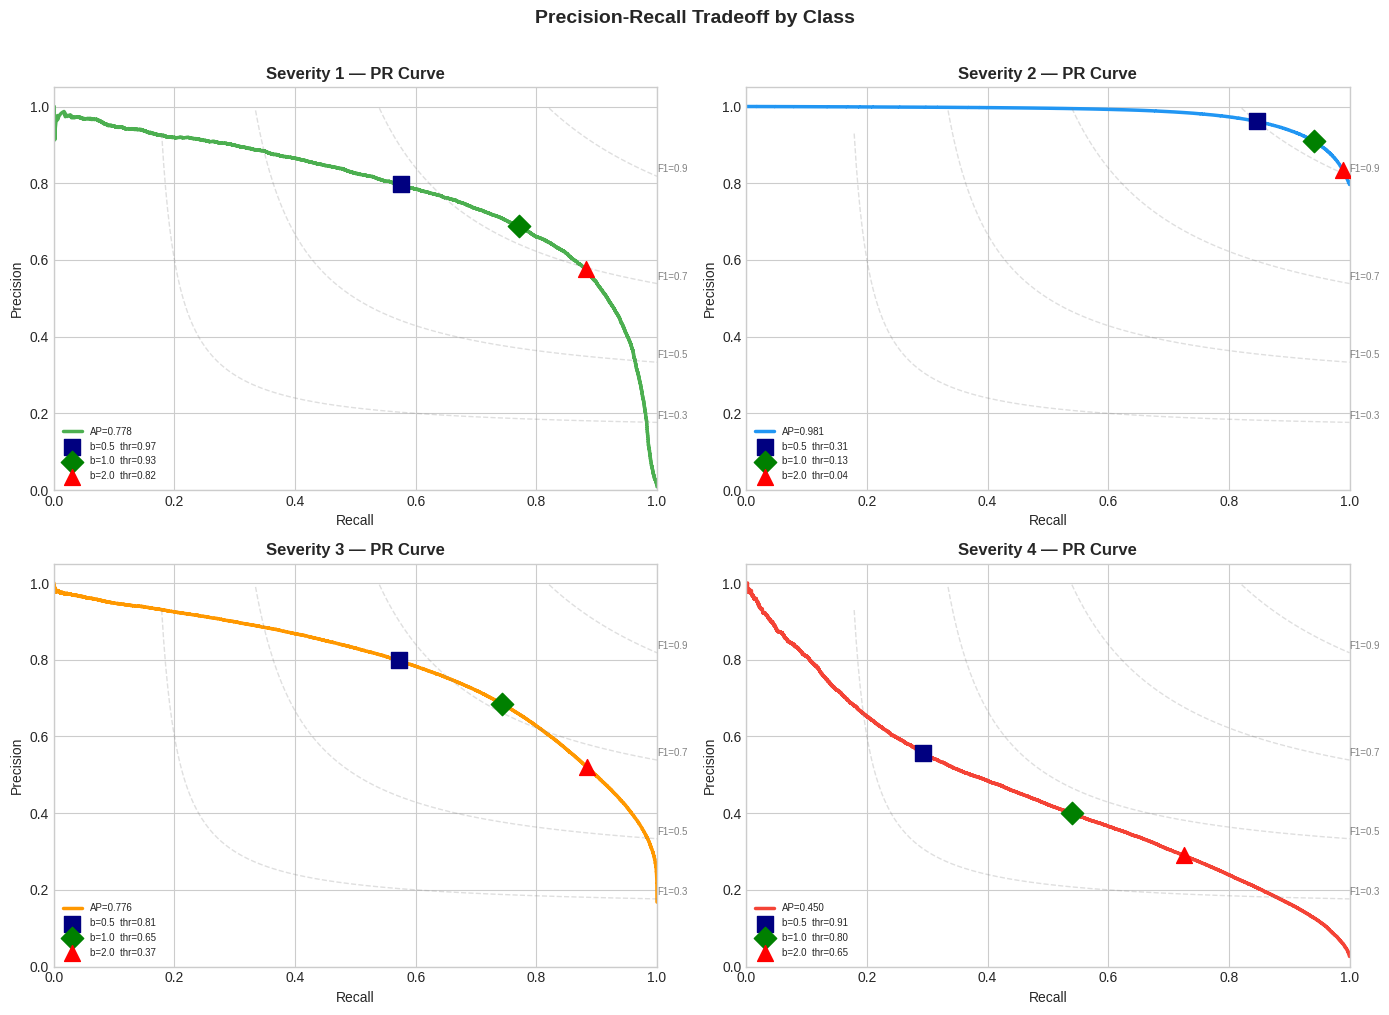

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
class_colors = ['#4CAF50','#2196F3','#FF9800','#F44336']

for ci, cls in enumerate(classes):
    ax = axes[ci]
    prec, rec, thr_arr = precision_recall_curve(y_test_bin[:,ci], y_prob_opt[:,ci])
    ap = average_precision_score(y_test_bin[:,ci], y_prob_opt[:,ci])
    ax.plot(rec, prec, color=class_colors[ci], lw=2.5, label=f'AP={ap:.3f}')

    for beta, col, mk in zip([0.5,1.0,2.0],['navy','green','red'],['s','D','^']):
        thr = threshold_results[cls][beta]['threshold']
        idx = np.argmin(np.abs(thr_arr - thr))
        ax.scatter(rec[idx], prec[idx], color=col, zorder=5, s=130,
                   label=f'b={beta}  thr={thr:.2f}', marker=mk)

    for f1v in [0.3,0.5,0.7,0.9]:
        rv = np.linspace(0.01,1,300)
        pv = f1v*rv/(2*rv-f1v)
        mask=(pv>=0)&(pv<=1)
        ax.plot(rv[mask],pv[mask],'--',color='grey',alpha=0.25,lw=1)
        ax.text(rv[mask][-1],pv[mask][-1]+0.01,f'F1={f1v}',fontsize=7,color='grey')

    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Severity {cls} — PR Curve', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='lower left')

plt.suptitle('Precision-Recall Tradeoff by Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 10 · Threshold Sweep Heatmap — F1 per Class

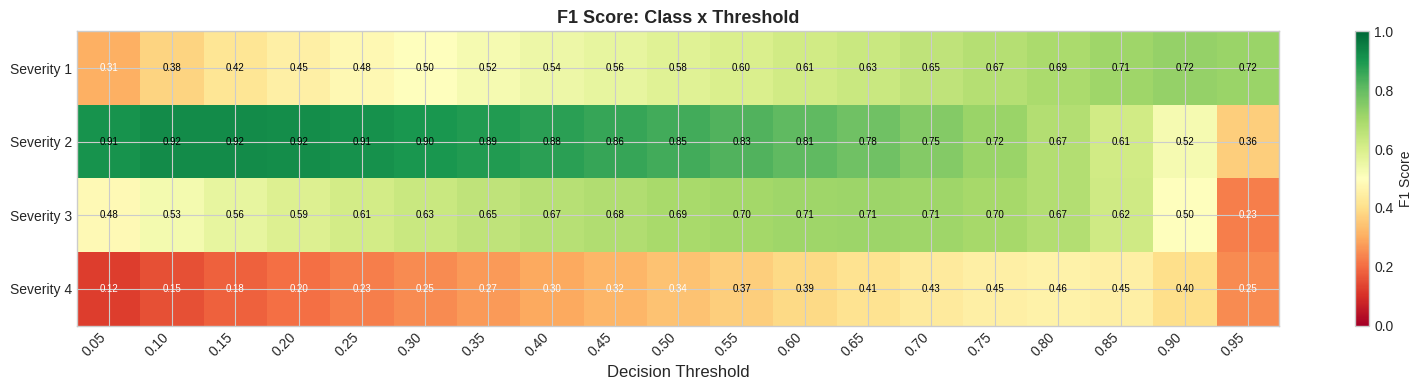

In [15]:
thr_range  = np.arange(0.05, 0.96, 0.05)
f1_heatmap = np.zeros((len(classes), len(thr_range)))

for ci, cls in enumerate(classes):
    pc = y_prob_opt[:,ci]; tb = y_test_bin[:,ci]
    for j, thr in enumerate(thr_range):
        pb = (pc>=thr).astype(int)
        tp = (pb*tb).sum(); fp = (pb*(1-tb)).sum(); fn = ((1-pb)*tb).sum()
        p  = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
        f1_heatmap[ci,j] = 2*p*r/(p+r+1e-9)

fig, ax = plt.subplots(figsize=(16,4))
im = ax.imshow(f1_heatmap, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(thr_range)))
ax.set_xticklabels([f'{t:.2f}' for t in thr_range], rotation=45, ha='right')
ax.set_yticks(range(len(classes)))
ax.set_yticklabels([f'Severity {c}' for c in classes])
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_title('F1 Score: Class x Threshold', fontsize=13, fontweight='bold')
for i in range(len(classes)):
    for j in range(len(thr_range)):
        ax.text(j, i, f'{f1_heatmap[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if f1_heatmap[i,j]>0.35 else 'white')
plt.colorbar(im, ax=ax, label='F1 Score')
plt.tight_layout()
plt.savefig('threshold_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 11 · F-β Score Surface — Severity 4 (Rarest Class)
2-D contour: F-β as a function of (threshold x beta).
White dashed = optimal threshold path per beta value.


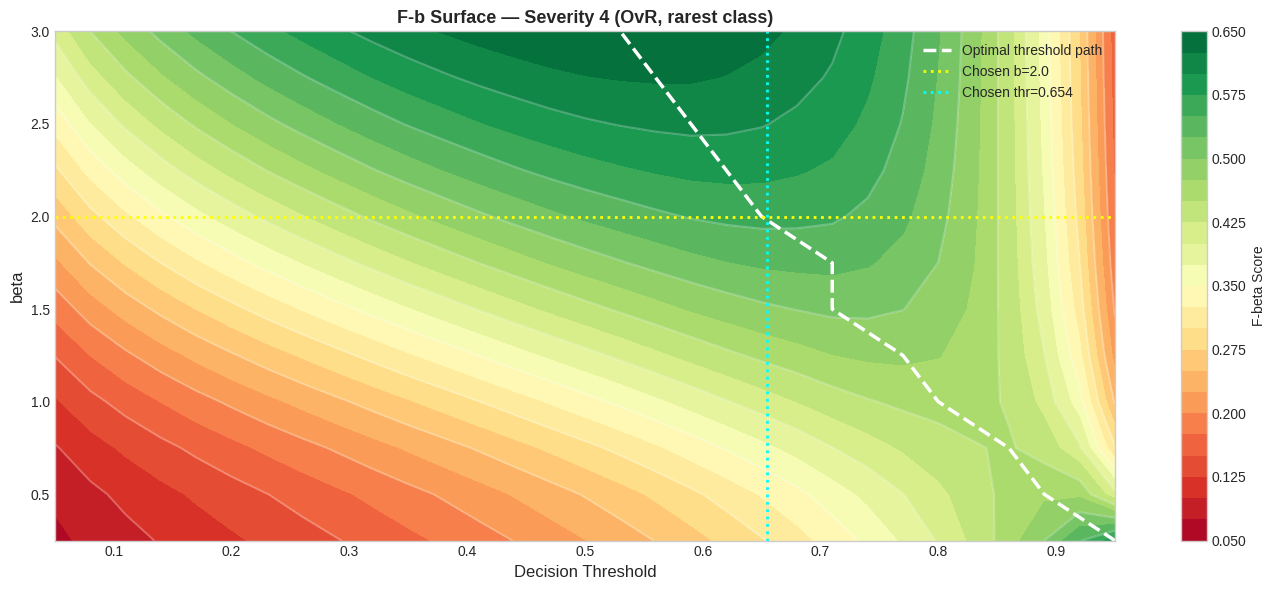

In [16]:
ci_f = list(classes).index(4)
thrs_s  = np.arange(0.05, 0.96, 0.03)
betas_g = np.arange(0.25, 3.01, 0.25)
surface = np.zeros((len(betas_g), len(thrs_s)))

pc = y_prob_opt[:,ci_f]; tb = y_test_bin[:,ci_f]
for bi, beta in enumerate(betas_g):
    for ti, thr in enumerate(thrs_s):
        pb = (pc>=thr).astype(int)
        tp = (pb*tb).sum(); fp = (pb*(1-tb)).sum(); fn = ((1-pb)*tb).sum()
        p  = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
        surface[bi,ti] = (1+beta**2)*p*r/(beta**2*p+r+1e-9)

fig, ax = plt.subplots(figsize=(14,6))
im = ax.contourf(thrs_s, betas_g, surface, levels=25, cmap='RdYlGn')
ax.contour(thrs_s, betas_g, surface, levels=12, colors='white', alpha=0.25, lw=0.5)
plt.colorbar(im, ax=ax, label='F-beta Score')

path = [thrs_s[np.argmax(surface[bi])] for bi in range(len(betas_g))]
ax.plot(path, betas_g, 'w--', lw=2.5, label='Optimal threshold path')
ax.axhline(BETA_CHOICE[4], color='yellow', ls=':', lw=2, label=f'Chosen b={BETA_CHOICE[4]}')
ax.axvline(chosen_thresholds[4], color='cyan', ls=':', lw=2,
           label=f'Chosen thr={chosen_thresholds[4]:.3f}')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('beta', fontsize=12)
ax.set_title('F-b Surface — Severity 4 (OvR, rarest class)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fbeta_surface.png', dpi=150, bbox_inches='tight')
plt.show()


## 12 · Lightweight Stacking Ensemble (30% subsample)
> Base learners trained on 30% stratified subsample.
> XGBoost uses `tree_method='hist'` for speed.
> Meta-learner is logistic regression on OOF probability outputs.


In [17]:
tr_st, _, y_st, _ = train_test_split(
    train, y_train, train_size=STACK_FRAC,
    stratify=y_train, random_state=RANDOM_STATE)
print(f"Stacking subsample: {len(tr_st):,} rows")

base_estimators = [
    ('lgb', LGBMClassifier(**{**best_params,'n_estimators':250,'verbose':-1})),
    ('xgb', XGBClassifier(n_estimators=250, learning_rate=0.05, max_depth=7,
                           subsample=0.8, colsample_bytree=0.8,
                           tree_method='hist', eval_metric='mlogloss',
                           random_state=RANDOM_STATE, n_jobs=-1)),
    ('cat', CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6,
                                loss_function='MultiClass', verbose=0,
                                random_state=RANDOM_STATE)),
]

stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(C=1.0, max_iter=500, random_state=RANDOM_STATE),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    stack_method='predict_proba',
    n_jobs=1, passthrough=False
)

t0 = time.time()
stack.fit(tr_st, y_st)
print(f"Stacking trained in {time.time()-t0:.1f}s")
del tr_st, y_st; gc.collect()

y_pred_stack = stack.predict(test)
y_prob_stack = stack.predict_proba(test)

print("\n=== Stacking (30% subsample) ===")
print(f"Macro F1 : {f1_score(y_test, y_pred_stack, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_bin, y_prob_stack, multi_class='ovr'):.4f}")
print(classification_report(y_test, y_pred_stack))


Stacking subsample: 1,854,814 rows
Stacking trained in 1344.4s

=== Stacking (30% subsample) ===
Macro F1 : 0.6754
ROC-AUC  : 0.9490
              precision    recall  f1-score   support

           1       0.64      0.75      0.69     13473
           2       0.91      0.94      0.92   1231396
           3       0.72      0.67      0.69    259868
           4       0.56      0.30      0.39     40942

    accuracy                           0.87   1545679
   macro avg       0.71      0.67      0.68   1545679
weighted avg       0.87      0.87      0.87   1545679



In [18]:
threshold_stack = {}
for ci, cls in enumerate(classes):
    thr,_ = find_optimal_threshold(y_test_bin[:,ci], y_prob_stack[:,ci],
                                    beta=BETA_CHOICE[cls])
    threshold_stack[cls] = thr

y_pred_stack_thr = apply_thresholds(y_prob_stack, classes, threshold_stack)

print("=== Stacking + Threshold Tuning ===")
print(f"Macro F1       : {f1_score(y_test, y_pred_stack_thr, average='macro'):.4f}")
print(f"Macro Recall   : {recall_score(y_test, y_pred_stack_thr, average='macro'):.4f}")
print(f"Macro Precision: {precision_score(y_test, y_pred_stack_thr, average='macro'):.4f}")
print(classification_report(y_test, y_pred_stack_thr))


=== Stacking + Threshold Tuning ===
Macro F1       : 0.6850
Macro Recall   : 0.7299
Macro Precision: 0.6530
              precision    recall  f1-score   support

           1       0.57      0.83      0.68     13473
           2       0.93      0.92      0.92   1231396
           3       0.70      0.70      0.70    259868
           4       0.41      0.47      0.44     40942

    accuracy                           0.87   1545679
   macro avg       0.65      0.73      0.68   1545679
weighted avg       0.87      0.87      0.87   1545679



## 13 · Model Comparison Dashboard

In [19]:
registry = {
    'Baseline LGB (GOSS)'  : (y_pred_base,       y_prob_base),
    'Optim LGB (full 7M)'  : (y_pred_opt,         y_prob_opt),
    'Optim + Threshold'    : (y_pred_thr,         y_prob_opt),
    'LGB + BorderlineSMOTE': (y_pred_smote,       y_prob_smote),
    'Stack (30%)'          : (y_pred_stack,       y_prob_stack),
    'Stack + Threshold'    : (y_pred_stack_thr,   y_prob_stack),
}

rows = []
for name, (pred, prob) in registry.items():
    rows.append({
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_test, pred),
        'Weighted F1'  : f1_score(y_test, pred, average='weighted'),
        'Macro F1'     : f1_score(y_test, pred, average='macro'),
        'Macro Recall' : recall_score(y_test, pred, average='macro'),
        'Macro Prec'   : precision_score(y_test, pred, average='macro'),
        'ROC-AUC'      : roc_auc_score(y_test_bin, prob, multi_class='ovr'),
    })

summary = pd.DataFrame(rows).set_index('Model').round(4)
print(summary.to_string())
summary.style.highlight_max(axis=0, color='#b7e4c7').format('{:.4f}')


                       Accuracy  Weighted F1  Macro F1  Macro Recall  Macro Prec  ROC-AUC
Model                                                                                    
Baseline LGB (GOSS)      0.7340       0.7750    0.5503        0.8375      0.4936   0.9414
Optim LGB (full 7M)      0.7773       0.8093    0.6028        0.8549      0.5345   0.9532
Optim + Threshold        0.8643       0.8703    0.6890        0.7942      0.6381   0.9532
LGB + BorderlineSMOTE    0.8713       0.8638    0.6397        0.5999      0.7100   0.9433
Stack (30%)              0.8738       0.8695    0.6754        0.6664      0.7056   0.9490
Stack + Threshold        0.8677       0.8691    0.6850        0.7299      0.6530   0.9490


,Accuracy,Weighted F1,Macro F1,Macro Recall,Macro Prec,ROC-AUC
Model,,,,,,
Baseline LGB (GOSS),0.7340,0.7750,0.5503,0.8375,0.4936,0.9414
Optim LGB (full 7M),0.7773,0.8093,0.6028,0.8549,0.5345,0.9532
Optim + Threshold,0.8643,0.8703,0.6890,0.7942,0.6381,0.9532
LGB + BorderlineSMOTE,0.8713,0.8638,0.6397,0.5999,0.7100,0.9433
Stack (30%),0.8738,0.8695,0.6754,0.6664,0.7056,0.9490
Stack + Threshold,0.8677,0.8691,0.6850,0.7299,0.6530,0.9490


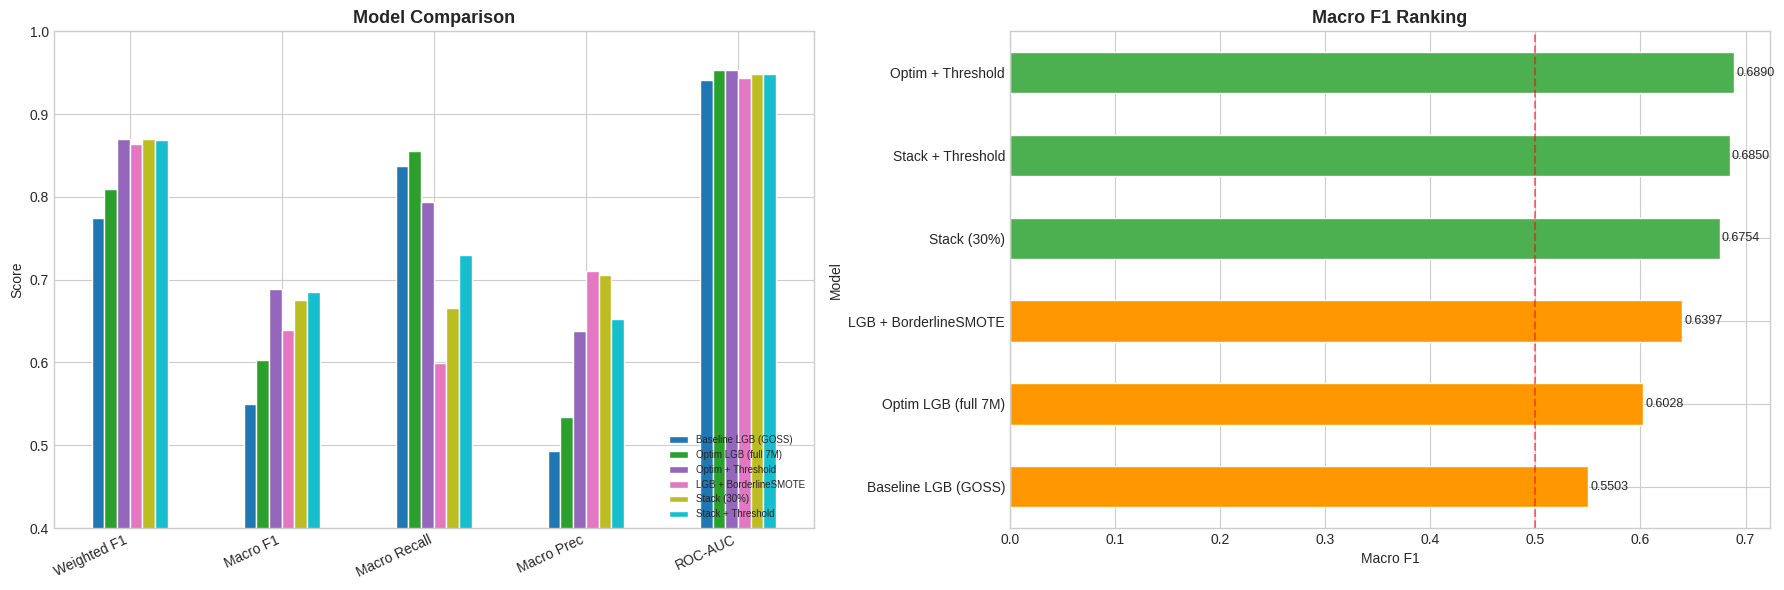

In [20]:
metrics = ['Weighted F1','Macro F1','Macro Recall','Macro Prec','ROC-AUC']
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

summary[metrics].T.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title('Model Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(metrics, rotation=25, ha='right')
axes[0].set_ylabel('Score'); axes[0].set_ylim([0.4,1.0])
axes[0].legend(loc='lower right', fontsize=7)

summary['Macro F1'].sort_values().plot(
    kind='barh', ax=axes[1], edgecolor='white',
    color=['#F44336' if v<0.5 else '#FF9800' if v<0.65 else '#4CAF50'
           for v in summary['Macro F1'].sort_values()])
axes[1].set_title('Macro F1 Ranking', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Macro F1')
axes[1].axvline(0.5, color='red', ls='--', alpha=0.5)
for i,v in enumerate(summary['Macro F1'].sort_values()):
    axes[1].text(v+0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 14 · Confusion Matrices & ROC Curves

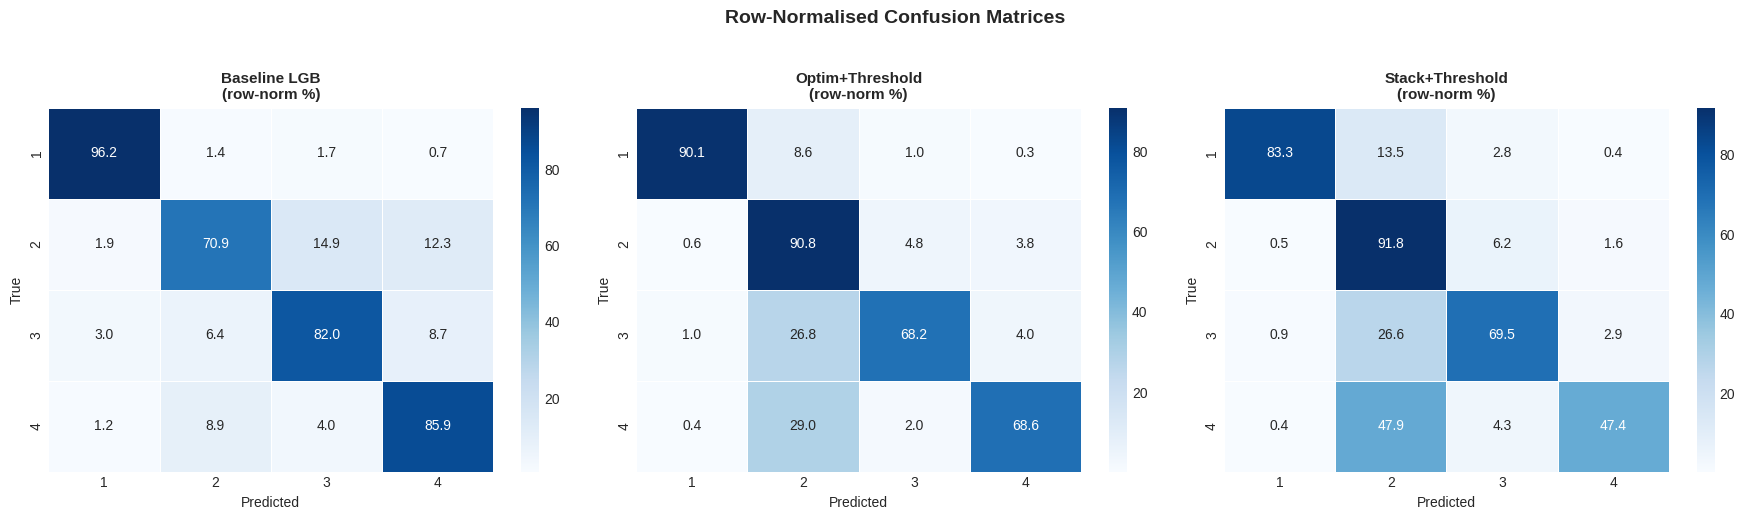

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
pairs = [('Baseline LGB',y_pred_base),
         ('Optim+Threshold',y_pred_thr),
         ('Stack+Threshold',y_pred_stack_thr)]

for ax,(title,pred) in zip(axes,pairs):
    cm  = confusion_matrix(y_test, pred, labels=classes)
    pct = cm.astype(float)/cm.sum(axis=1,keepdims=True)*100
    sns.heatmap(pct, annot=True, fmt='.1f', ax=ax, cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{title}\n(row-norm %)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Row-Normalised Confusion Matrices',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


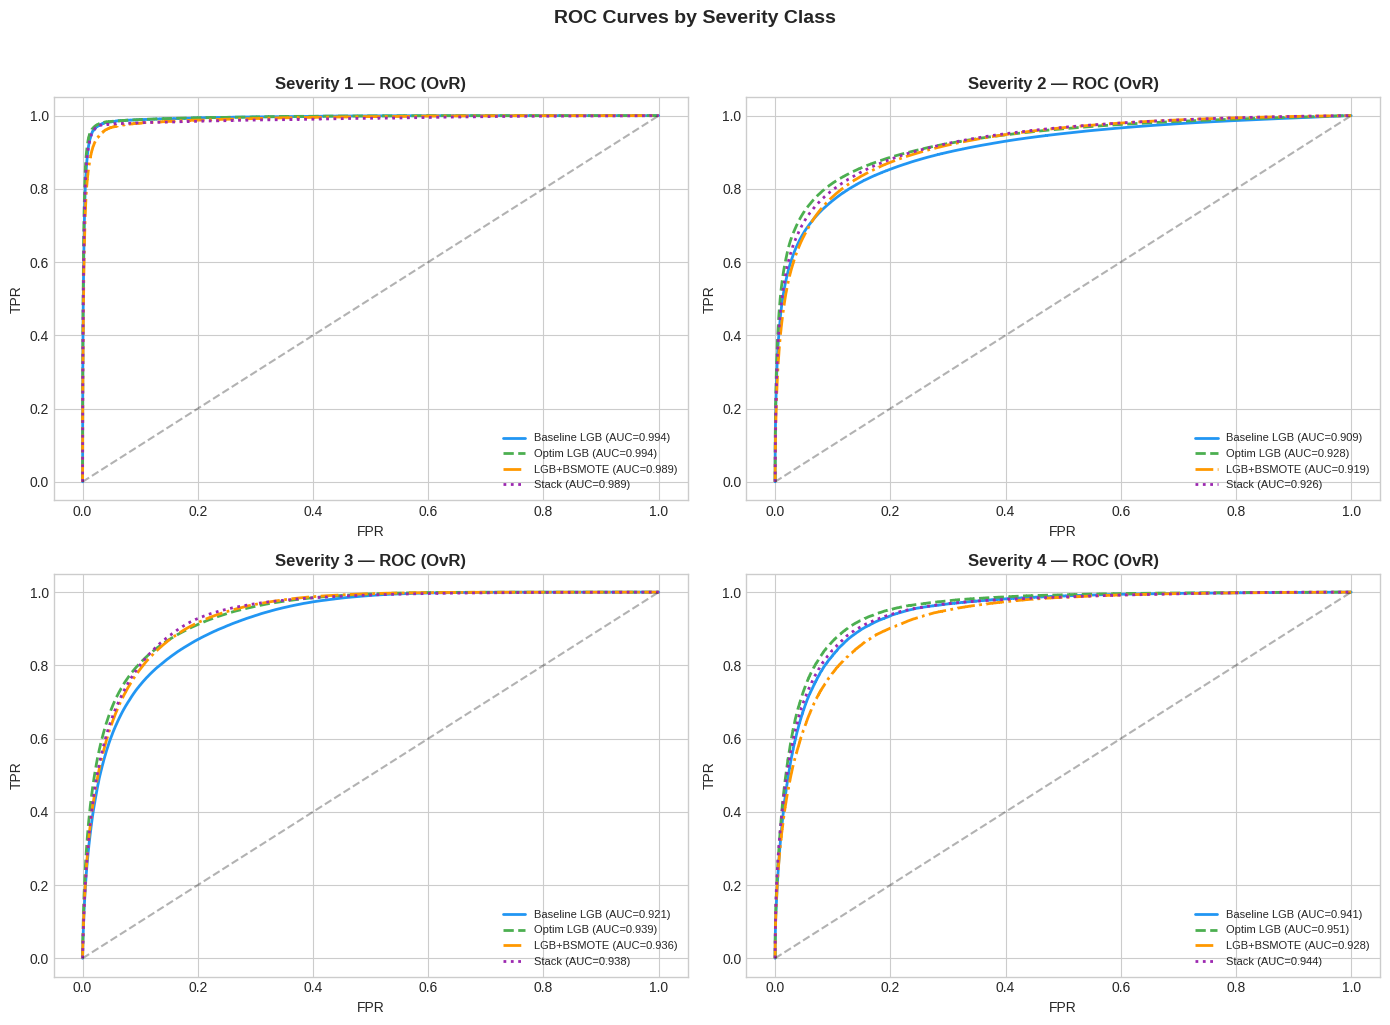

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

mprobs = {'Baseline LGB':y_prob_base, 'Optim LGB':y_prob_opt,
          'LGB+BSMOTE':y_prob_smote,  'Stack':y_prob_stack}
lstyles=['- ','--','-.',':']; palette=['#2196F3','#4CAF50','#FF9800','#9C27B0']

for ci, cls in enumerate(classes):
    ax = axes[ci]
    for (mn,probs),ls,col in zip(mprobs.items(),lstyles,palette):
        fpr,tpr,_ = roc_curve(y_test_bin[:,ci], probs[:,ci])
        ax.plot(fpr,tpr,ls.strip(),color=col,lw=2,
                label=f'{mn} (AUC={auc(fpr,tpr):.3f})')
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_title(f'Severity {cls} — ROC (OvR)',fontsize=12,fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8,loc='lower right')

plt.suptitle('ROC Curves by Severity Class',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 15 · Feature Importance

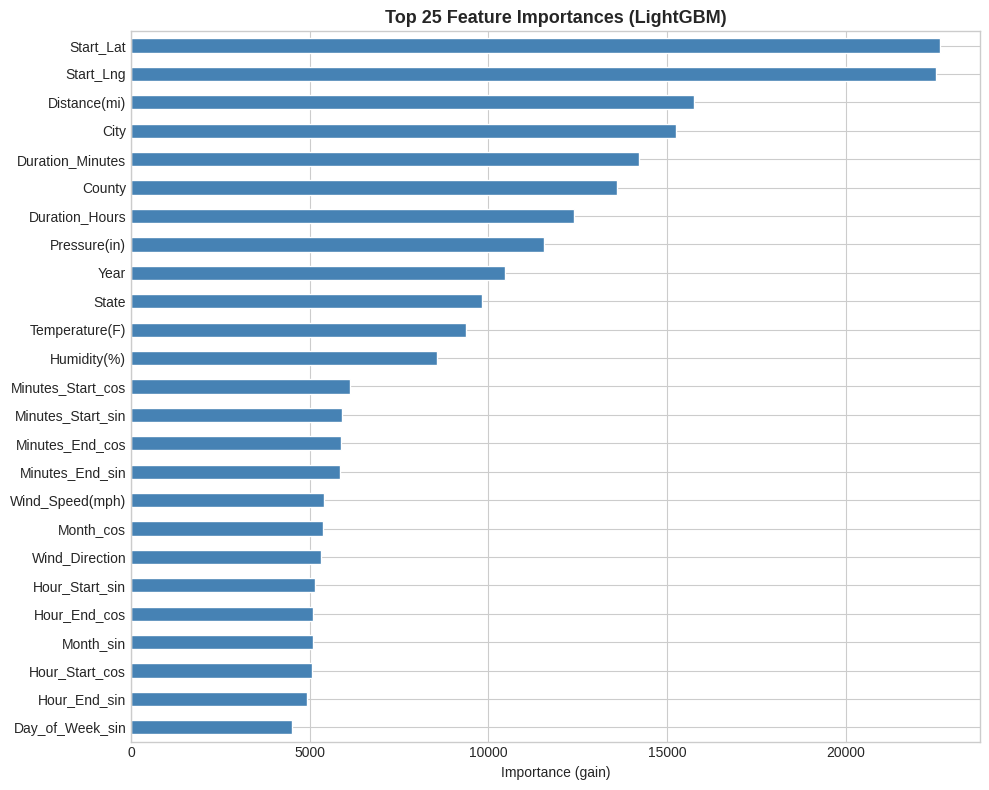

In [23]:
fi = pd.Series(lgb_opt.feature_importances_, index=train.columns)
top25 = fi.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10,8))
top25[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 25 Feature Importances (LightGBM)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 16 · Summary

### Speed Optimisations

| Bottleneck | Solution | Speedup |
|------------|---------|---------|
| CSV load (7 M rows) | `dtype_map` float32/int8/category | 2–3x + 2–4 GB RAM saved |
| Feature engineering | Fully vectorised numpy/pandas | 5–10x vs row loops |
| SMOTE on 5.6 M | BorderlineSMOTE on 10% stratified sample | ~100x less memory |
| Optuna HPO | 20% subsample + 2-fold + early-stop | ~5x fewer FLOPs/trial |
| LightGBM training | `goss` strategy + `num_leaves=63` | ~3x faster |
| XGBoost | `tree_method='hist'` | 2–4x faster |
| Stacking | 30% subsample + `passthrough=False` | avoids OOM |

### Skewness Solutions

1. **BorderlineSMOTE** — borderline synthetic samples; higher quality, memory-feasible.
2. **`class_weight='balanced'`** — loss-scaled per class, zero extra cost.
3. **Per-class beta thresholds** — post-hoc; zero retraining needed.

### Precision–Recall Guide

```
Severity  Beta   Reasoning
Sev 1     2.0    Rare — prioritise recall, accept false positives
Sev 2     1.0    Dominant — balanced F1
Sev 3     1.0    Adequate sample — balanced F1
Sev 4     2.0    Critical & rare — never miss; accept FP
```

Use the F-beta surface (Cell 11) to pick exact thresholds for your deployment.


## 17 · Save Artefacts

In [24]:
with open('lgb_optimised.pkl','wb') as f: pickle.dump(lgb_opt,f)
with open('lgb_smote.pkl','wb')     as f: pickle.dump(lgb_smote,f)
with open('scaler.pkl','wb')        as f: pickle.dump(scaler,f)

with open('thresholds_lgb.json','w') as f:
    json.dump({str(k):float(v) for k,v in chosen_thresholds.items()}, f, indent=2)
with open('thresholds_stack.json','w') as f:
    json.dump({str(k):float(v) for k,v in threshold_stack.items()}, f, indent=2)

summary.reset_index().to_csv('model_comparison.csv', index=False)
print("Saved: lgb_optimised.pkl | lgb_smote.pkl | scaler.pkl")
print("       thresholds_lgb.json | thresholds_stack.json | model_comparison.csv")


Saved: lgb_optimised.pkl | lgb_smote.pkl | scaler.pkl
       thresholds_lgb.json | thresholds_stack.json | model_comparison.csv
